In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List
from time import time
import itertools

# -------------------------------------------------------------
# Your existing modules (keep same as before)
# -------------------------------------------------------------
from calib.configs import CalibrationConfig
from calib.emulator import DeterministicSimulator
from calib.online_calibrator import OnlineBayesCalibrator, crps_gaussian
from calib.bpc import BayesianProjectedCalibration
from calib.bcp_bocpd import *  # StandardBOCPD_BPC

In [2]:
# -------------------------------------------------------------
# Simulator (Config2)
# -------------------------------------------------------------
def computer_model_config2_np(x: np.ndarray, theta: np.ndarray) -> np.ndarray:
    x = np.atleast_2d(x)
    theta = np.atleast_2d(theta)
    th = theta[:, [0]]
    xx = x[:, [0]]
    return (np.sin(5.0 * th * xx) + 5.0 * xx).reshape(-1)


def computer_model_config2_torch(x: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    if x.dim() == 1:
        x = x[:, None]
    if theta.dim() == 1:
        theta = theta[None, :]
    return torch.sin(5.0 * theta[:, 0:1] * x[:, 0:1]) + 5.0 * x[:, 0:1]


# -------------------------------------------------------------
# True physical system η(x; φ)
# -------------------------------------------------------------
def physical_system(x: np.ndarray, phi: np.ndarray) -> np.ndarray:
    """
    φ = [a1, a2, a3]
    η(x) = a1 * x * cos(a2 * x) + a3 * x
    """
    x = x.reshape(-1)
    a1, a2, a3 = phi
    return a1 * x * np.cos(a2 * x) + a3 * x


# -------------------------------------------------------------
# Data stream with 3 sudden changepoints
# -------------------------------------------------------------
class SuddenChangeDataStream:
    """
    total_T observations, generated in batches.
    changepoints are in observation-time units (same as t counter).
    """

    def __init__(
        self,
        total_T: int,
        batch_size: int,
        noise_sd: float,
        cp_times: List[int],
        phi_segments: List[np.ndarray],  # length = len(cp_times)+1
        seed: int,
    ):
        assert len(phi_segments) == len(cp_times) + 1
        self.T = int(total_T)
        self.bs = int(batch_size)
        self.noise_sd = float(noise_sd)
        self.cp_times = [int(t) for t in cp_times]
        self.phi_segments = [np.asarray(p, dtype=float) for p in phi_segments]
        self.rng = np.random.RandomState(int(seed))

        self.t = 0
        self.phi_history = []  # per-batch phi (at batch start)
        self.seg_history = []  # per-batch segment id

    def _seg_id(self, t: int) -> int:
        # number of cps with time <= t
        k = 0
        for c in self.cp_times:
            if t >= c:
                k += 1
            else:
                break
        return k

    def true_phi(self, t: int) -> np.ndarray:
        return self.phi_segments[self._seg_id(t)].copy()

    def next(self) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.t >= self.T:
            raise StopIteration

        # X = self.rng.rand(self.bs, 1)
        u = (np.arange(self.bs) + self.rng.rand(self.bs)) / self.bs     
        X = u[:, None]
        self.rng.shuffle(X)

        phi_t = self.true_phi(self.t)

        y = physical_system(X, phi_t) + self.noise_sd * self.rng.randn(self.bs)

        self.phi_history.append(phi_t.copy())
        self.seg_history.append(self._seg_id(self.t))

        self.t += self.bs

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# -------------------------------------------------------------
# Oracle θ*(φ) via dense grid search
# -------------------------------------------------------------
def oracle_theta(phi: np.ndarray, grid: np.ndarray) -> float:
    """
    θ* = argmin || η(x;φ) - y_s(x,θ) ||^2  (approximated by dense x-grid)
    """
    x = np.linspace(0, 1, 400).reshape(-1, 1)
    eta = physical_system(x, phi)

    errs = []
    for th in grid:
        ys = computer_model_config2_np(x, np.array([th]))
        errs.append(np.mean((eta - ys) ** 2))

    return float(grid[int(np.argmin(errs))])


# -------------------------------------------------------------
# Build 4 segment-phis (3 changepoints), centered around phi2=7.5
# magnitude controls how far we move phi[1] (the "a2" term)
# -------------------------------------------------------------
def build_phi_segments_centered(delta: float, center: float = 7.5):
    """
    4 regimes, 3 changepoints
    phi[1] strictly increasing
    mean(phi[1]) = center
    adjacent jump size = delta
    """
    a1, a3 = 5.0, 5.0

    phi2_vals = np.array([
        center - 1.5 * delta,
        center - 0.5 * delta,
        center + 0.5 * delta,
        center + 1.5 * delta,
    ])

    return [
        np.array([a1, v, a3], dtype=float)
        for v in phi2_vals
    ]

In [36]:
seg_len_L = 200
delta_mag = 0.5
methods = {
    # "BOCPD-PF": dict(type="bocpd", mode="standard"),
    # "BPC-80": dict(type="bpc"),
    "BOCPD-BPC": dict(type="bpc_bocpd"),
    # "R-BOCPD-PF-usediscrepancy": dict(type="bocpd", mode="restart", use_discrepancy=True),
    # "R-BOCPD-PF-nodiscrepancy": dict(type="bocpd", mode="restart", use_discrepancy=False),
    # "BPC-80": dict(type="bpc"),
}
batch_size = 20
seed = 1
noise_sd = 0.2
phi_center = 7.5
out_dir: str = ".",

In [37]:
seg_len_L = int(seg_len_L)
bs = int(batch_size)
if seg_len_L % bs != 0:
    raise ValueError(f"seg_len_L ({seg_len_L}) must be divisible by batch_size ({bs})")

total_T = 4 * seg_len_L
cp_times = [seg_len_L, 2 * seg_len_L, 3 * seg_len_L]
phi_segments = build_phi_segments_centered(delta=delta_mag, center=phi_center)

print(f"\n=== Sudden experiment: L={seg_len_L}, delta={delta_mag:.4f}, bs={bs}, seed={seed} ===")
print(f"    cp_times={cp_times}, total_T={total_T}")
print(f"    phi[1] values={[p[1] for p in phi_segments]} (center={phi_center})")

# oracle grid
theta_grid = np.linspace(0, 3, 600)

# shared stream for oracle phi_history reference (per-batch)
stream_ref = SuddenChangeDataStream(
    total_T=total_T,
    batch_size=bs,
    noise_sd=noise_sd,
    cp_times=cp_times,
    phi_segments=phi_segments,
    seed=seed,
)

# prior
def prior_sampler(N: int):
    return torch.rand(N, 1) * 3.0

results = {}


=== Sudden experiment: L=200, delta=0.5000, bs=20, seed=1 ===
    cp_times=[200, 400, 600], total_T=800
    phi[1] values=[np.float64(6.75), np.float64(7.25), np.float64(7.75), np.float64(8.25)] (center=7.5)


In [38]:
for name, meta in methods.items():
    print(f"  -> {name}")

  -> BOCPD-BPC


In [23]:
print(f"  -> {name}")
t0 = time()

theta_hist: List[float] = []
rmse_hist: List[float] = []
others_hist: List[dict] = []
total_obs = 0

# fresh stream per method (same data given same seed)
stream = SuddenChangeDataStream(
    total_T=total_T,
    batch_size=bs,
    noise_sd=noise_sd,
    cp_times=cp_times,
    phi_segments=phi_segments,
    seed=seed,
)

# ---------- BOCPD ----------
if meta["type"] == "bocpd":
    cfg = CalibrationConfig()
    cfg.bocpd.bocpd_mode = meta["mode"]
    cfg.bocpd.use_restart = True

    if meta["mode"] == "restart":
        cfg.model.use_discrepancy = meta["use_discrepancy"]

    emulator = DeterministicSimulator(
        func=computer_model_config2_torch,
        enable_autograd=True,
    )
    calib = OnlineBayesCalibrator(cfg, emulator, prior_sampler)

  -> BPC-80


In [24]:
Xb, Yb = stream.next()
report_sub_hist = None

if total_obs > 0:
    pred = calib.predict_batch(Xb)
    pred_comp = calib.predict_complete(Xb, Yb)
    report_sub_hist = (pred_comp["crps_sim"].item(),pred_comp["experts_logpred"],pred_comp["var_sim"])
    # print(name, total_obs, report_hist[-1])
    # rmse_hist.append(
    #     float(torch.sqrt(((pred["mu"] - Yb) ** 2).mean()))
    # )
    rmse_hist.append(
        float(torch.sqrt(((pred["mu_sim"] - Yb) ** 2).mean()))
    )

rec = calib.step_batch(Xb, Yb, verbose=False)

# NOTE: assumes your OnlineBayesCalibrator._aggregate_particles(q)
# returns (mean, var_or_cov, lo, hi) where mean/lo/hi are vectors.
mean_theta, var_theta, lo_theta, hi_theta = calib._aggregate_particles(0.9)

theta_hist.append(float(mean_theta[0]))
# var_theta may be scalar/vec/cov; keep first dim as scalar for logging
v0 = float(var_theta[0]) if np.ndim(var_theta) >= 1 else float(var_theta)

ess_gini_info = []
for ei, e in enumerate(calib.bocpd.experts):
    ps = e.pf.particles
    unique_ratio = float(ps.unique_ratio())
    entropy_1d_histogram = float(ps.entropy_1d_histogram())
    # print(ei, unique_ratio, entropy_1d_histogram)
    ess_gini_info.append({"expert_id": ei, "unique_ratio": unique_ratio, "entropy_1d_histogram": entropy_1d_histogram})

others_hist.append(
    dict(
        did_restart=bool(rec.get("did_restart", False)),
        var=v0,
        lo=float(lo_theta[0]),
        hi=float(hi_theta[0]),
        ess_gini_info=ess_gini_info,
        seg_id=int(stream.seg_history[-1]),
        t=int(total_obs),
        pf_info=rec["pf_diags"],
        report_sub_hist=report_sub_hist,
        pf_health_info=ess_gini_info,
    )
)

total_obs += bs

In [ ]:
top0_particles_hist = []
experts = calib.bocpd.experts

weights = torch.tensor([e.log_mass for e in experts])
top_idx = torch.argmax(weights).item()
top_expert = experts[top_idx]

particles = top_expert.pf.particles.theta  
pw = top_expert.pf.particles.weights()

particles_1d = particles.squeeze(-1).detach().cpu()
pw_1d = pw.squeeze(-1).detach().cpu()

top0_particles_hist.append((particles_1d, pw_1d))

In [19]:
all_experts_hist = []
xperts = calib.bocpd.experts

batch_particles = []
batch_weights = []
batch_logmass = []

for e in experts:
    # particles
    particles = e.pf.particles.theta          # (N,1)
    particles_1d = particles.squeeze(-1).detach().cpu()

    # weights
    pw = e.pf.particles.weights()             # (N,)
    pw_1d = pw.squeeze(-1).detach().cpu()

    # log mass
    log_mass = float(e.log_mass)

    batch_particles.append(particles_1d)
    batch_weights.append(pw_1d)
    batch_logmass.append(log_mass)

batch_dict = dict(
    particles=batch_particles,      # list length E
    weights=batch_weights,          # list length E
    log_mass=torch.tensor(batch_logmass)  # (E,)
)

all_experts_hist.append(batch_dict)

In [28]:
Xb, Yb = stream.next()
X_hist = None
W = 80
bpc = None
crps_sim = None
if X_hist is None:
    X_hist, y_hist = Xb.numpy(), Yb.numpy()
else:
    X_hist = np.concatenate([X_hist, Xb.numpy()], axis=0)
    y_hist = np.concatenate([y_hist, Yb.numpy()], axis=0)
if X_hist.shape[0] >= W:
    X_hist = X_hist[-W:]
    y_hist = y_hist[-W:]

if total_obs > 0 and bpc is not None:
    mu_np, var_np = bpc.predict_sim(Xb.detach().cpu().numpy())
    mu_t, var_t = torch.tensor(mu_np, dtype=Yb.dtype, device=Yb.device), torch.tensor(var_np, dtype=Yb.dtype, device=Yb.device) 
    rmse_hist.append(float(torch.sqrt(((mu_t - Yb) ** 2).mean())))
    crps_sim = crps_gaussian(mu_t, var_t, Yb)

X_all, y_all = X_hist, y_hist

bpc = BayesianProjectedCalibration(
    theta_lo=np.array([0.0]),
    theta_hi=np.array([3.0]),
    noise_var=float(noise_sd ** 2),
    y_sim=computer_model_config2_np,
)
X_grid = np.linspace(0, 1, 400).reshape(-1, 1)
bpc.fit(X_all, y_all, X_grid, n_eta_draws=500, n_restart=10, gp_fit_iters=200)

theta_hist.append(float(bpc.theta_mean[0]))
entropy_info = bpc.entropy_theta()
others_hist.append(
    dict(
        did_restart=False,
        var=float(bpc.theta_var[0]) if bpc.theta_var is not None else float("nan"),
        lo=float("nan"),
        hi=float("nan"),
        seg_id=int(stream.seg_history[-1]),
        t=int(total_obs),
        entropy=entropy_info,
        crps_sim=crps_sim,
    )
)

c:\Users\yxu59\AppData\Local\miniconda3\envs\jumpGP\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\yxu59\AppData\Local\miniconda3\envs\jumpGP\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


In [34]:
theta_samples_bpc = torch.tensor(bpc.theta_samples).squeeze(-1)

In [35]:
particles_1d.shape, theta_samples_bpc.shape

(torch.Size([1024]), torch.Size([500]))

In [45]:
calib = StandardBOCPD_BPC(
    theta_lo=np.array([0.0]),
    theta_hi=np.array([3.0]),
    noise_var=float(noise_sd ** 2),
    y_sim=computer_model_config2_np,
    X_grid=np.linspace(0, 1, 400).reshape(-1, 1),
    # if your class supports: hazard_h/topk/etc, put them in meta["params"]
    **meta.get("params", {}),
    )


Xb, Yb = stream.next()
crps_sim = None
total_obs = 0
if total_obs > 0:
    mu, var = calib.predict_sim(Xb)
    mu_t, var_t = torch.tensor(mu, dtype=Yb.dtype, device=Yb.device), torch.tensor(var, dtype=Yb.dtype, device=Yb.device)
    rmse_hist.append(float(torch.sqrt(((mu_t - Yb) ** 2).mean())))
    crps_sim = crps_gaussian(mu_t, var_t, Yb)

info = calib.step_batch(Xb.detach().cpu().numpy(), Yb.detach().cpu().numpy())

# assumes your StandardBOCPD_BPC._aggregate_particles(q) exists and returns (mean, cov/var, lo, hi)
theta_mean, theta_var, theta_lo, theta_hi = calib._aggregate_particles(0.9)

theta_hist.append(float(theta_mean[0]))
# theta_var could be vector or cov; keep first dim scalar

c:\Users\yxu59\AppData\Local\miniconda3\envs\jumpGP\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\yxu59\AppData\Local\miniconda3\envs\jumpGP\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


In [49]:
v0 = float(theta_var[0][0]) if np.ndim(theta_var) >= 1 else float(theta_var)

others_hist.append(
    dict(
        did_restart=bool(info.get("did_restart", False)),
        var=v0,
        lo=float(theta_lo[0]) if np.ndim(theta_lo) >= 1 else float(theta_lo),
        hi=float(theta_hi[0]) if np.ndim(theta_hi) >= 1 else float(theta_hi),
        seg_id=int(stream.seg_history[-1]),
        t=int(total_obs),
        crps_sim=crps_sim,
    )
)

In [52]:
for e in calib.experts:
    print(e.logw, e.bpc.theta_samples.shape)

-104.88959900248767 (500, 1)
0.0 (500, 1)


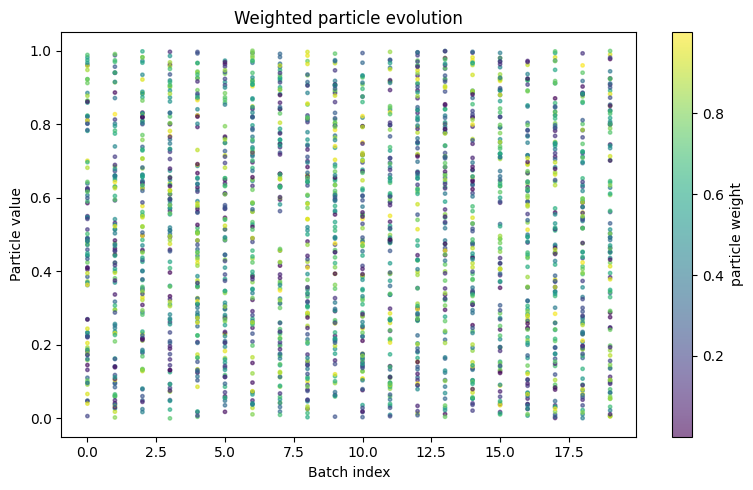

In [65]:
from calib.vis_utils import plot_particle_scatter_weighted, plot_ridgeline, plot_weighted_boxplot, plot_particle_evolution, plot_weighted_histograms
top0_particles_tensor, top0_weights_tensor = torch.rand(20, 100), torch.rand(20, 100)
plot_particle_scatter_weighted(top0_particles_tensor, top0_weights_tensor)
# plot_ridgeline(top0_particles_tensor, top0_weights_tensor)
# plot_weighted_boxplot(top0_particles_tensor, top0_weights_tensor)
# plot_particle_evolution(top0_particles_tensor, top0_weights_tensor)
# plot_weighted_histograms(top0_particles_tensor, top0_weights_tensor)

In [177]:
import torch
data = torch.load("./figs/sudden_grid_outputs/v1_debug/sudden_L120_delta2_bs20_seed456_results.pt", weights_only=False)

In [116]:
data["BOCPD-PF"]["theta_oracle"]

array([1.25208681, 1.25208681, 1.25208681, 1.25208681, 1.25208681,
       1.25208681, 1.73789649, 1.73789649, 1.73789649, 1.73789649,
       1.73789649, 1.73789649, 2.12854758, 2.12854758, 2.12854758,
       2.12854758, 2.12854758, 2.12854758, 2.48914858, 2.48914858,
       2.48914858, 2.48914858, 2.48914858, 2.48914858])

In [174]:
# for name in ['BOCPD-PF', 'BOCPD-BPC', 'BPC-80', 'R-BOCPD-PF-usediscrepancy', 'R-BOCPD-PF-nodiscrepancy']:
method_dict = {}
for name in ['BOCPD-PF', 'BOCPD-BPC', 'R-BOCPD-PF-usediscrepancy', 'R-BOCPD-PF-nodiscrepancy']:
    particles_total, weights_total = [], []
    for i in range(len(data[name]['top0_particles_hist'])):
        max_idx = torch.argmax(data[name]['top0_particles_hist'][i]["log_mass"])
        particles_total.append(data[name]['top0_particles_hist'][i]["particles"][max_idx].reshape(1, -1))
        try: 
            weights_total.append(data[name]['top0_particles_hist'][i]["weights"][max_idx].reshape(1, -1))
        except:
            weights_total.append(torch.ones(1, 500)/500)
        # print(data['BOCPD-PF']['top0_particles_hist'][i][0][max_idx])
    particles_total_bocpdpf = torch.cat(particles_total, dim=0)
    weights_total_bocpdpf = torch.cat(weights_total, dim=0)
    method_dict[name] = (particles_total_bocpdpf, weights_total_bocpdpf)
# particles_total_bocpdpf.shape

# plot_particle_scatter_weighted(particles_total_bocpdpf, weights_total_bocpdpf)

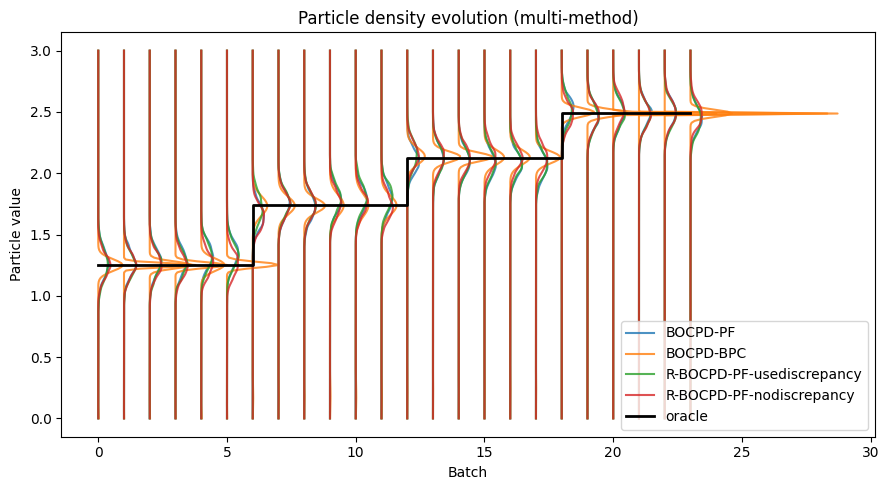

In [175]:
# from calib.vis_utils import plot_vertical_density, plot_vertical_density_oracle_centered
plot_vertical_density(method_dict, oracle=data["BOCPD-PF"]["theta_oracle"])

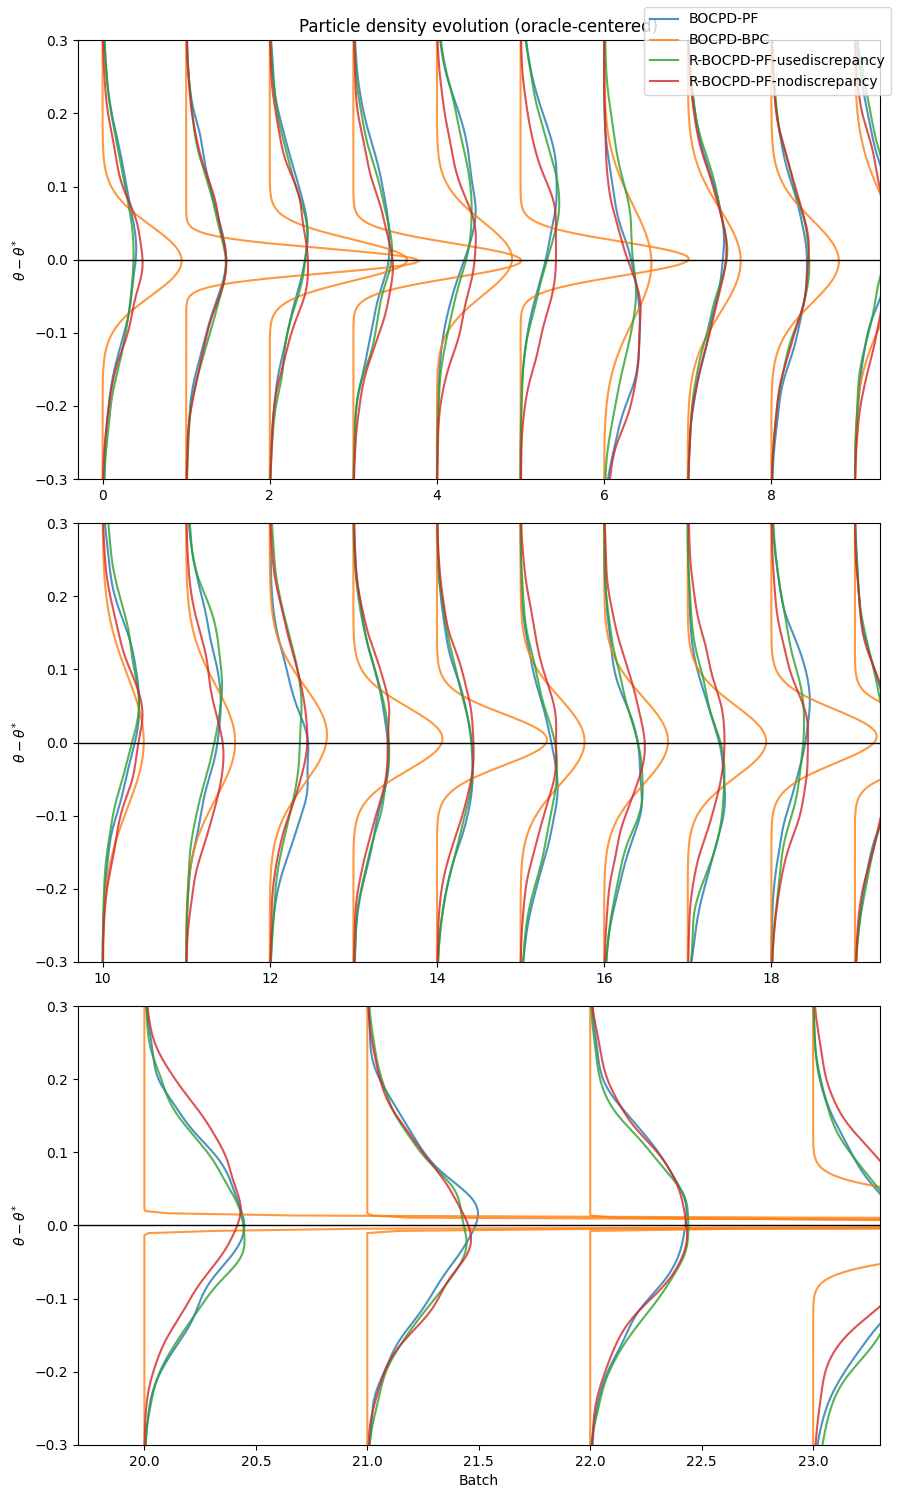

In [176]:
plot_vertical_density_oracle_centered_multilayer(method_dict, data["BOCPD-PF"]["theta_oracle"])

In [138]:
# from scipy.stats import gaussian_kde

# def plot_expert_density(batch_dict, grid_points=200, width=0.4):

#     import numpy as np
#     import matplotlib.pyplot as plt

#     # 找全局范围
#     y_min, y_max = 0, 3
#     y_grid = np.linspace(y_min, y_max, grid_points)

#     plt.figure(figsize=(9,5))

#     for b in sorted(batch_dict.keys()):

#         experts = batch_dict[b]

#         for e_idx, (particles, weights, logmass) in enumerate(experts):

#             p = particles.detach().cpu().numpy()
#             w = weights.detach().cpu().numpy()

#             kde = gaussian_kde(p, weights=w)
#             density = kde(y_grid)

#             if density.max() > 0:
#                 density = density / density.max() * width

#             alpha = min(float(np.exp(logmass)), 1.0)

#             plt.plot(
#                 b + density,
#                 y_grid,
#                 alpha=alpha,
#                 color=f"C{e_idx % 10}"
#             )

#     plt.xlabel("Batch")
#     plt.ylabel("Particle value")
#     plt.title("Expert density evolution")
#     plt.show()

# from scipy.stats import gaussian_kde
# import numpy as np
# import matplotlib.pyplot as plt
# import torch

# def plot_expert_density(batch_dict, grid_points=200, width=0.4):

#     y_min, y_max = 0, 3
#     y_grid = np.linspace(y_min, y_max, grid_points)

#     plt.figure(figsize=(9,5))

#     for b in sorted(batch_dict.keys()):

#         experts = batch_dict[b]

#         # ===== 先按 logmass 排序 =====
#         experts_sorted = sorted(
#             experts,
#             key=lambda x: float(x[2]),
#             reverse=True
#         )

#         # ===== 归一化 mass =====
#         logmass_list = torch.tensor([float(e[2]) for e in experts_sorted])
#         mass = torch.exp(logmass_list - logmass_list.max())
#         mass = mass / mass.sum()

#         for rank, (particles, weights, logmass) in enumerate(experts_sorted):

#             p = particles.detach().cpu().numpy()
#             w = weights.detach().cpu().numpy()

#             kde = gaussian_kde(p, weights=w)
#             density = kde(y_grid)

#             if density.max() > 0:
#                 density = density / density.max() * width

#             alpha = float(mass[rank])

#             plt.plot(
#                 b + density,
#                 y_grid,
#                 alpha=alpha,
#                 color=f"C{rank % 10}"
#             )

#     plt.xlabel("Batch")
#     plt.ylabel("Particle value")
#     plt.title("Expert density evolution (rank-colored)")
#     plt.show()

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_expert_density_ranked(batch_dict, grid_points=200, width=0.4):

    y_min, y_max = 0, 3
    y_grid = np.linspace(y_min, y_max, grid_points)

    plt.figure(figsize=(9,5))

    for b in sorted(batch_dict.keys()):

        experts = batch_dict[b]

        # ===== 按 logmass 排序（降序）=====
        experts_sorted = sorted(
            experts,
            key=lambda x: float(x[2]),
            reverse=True
        )

        for rank, (particles, weights, logmass) in enumerate(experts_sorted):

            p = particles.detach().cpu().numpy()
            w = weights.detach().cpu().numpy()

            kde = gaussian_kde(p, weights=w)
            density = kde(y_grid)

            if density.max() > 0:
                density = density / density.max() * width

            # 主 expert 更粗
            lw = 2.0 if rank == 0 else 1.0

            if b == 0:
                plt.plot(
                    b + density,
                    y_grid,
                    color=f"C{rank % 10}",
                    linewidth=lw,
                    alpha=0.9,
                    label=f"Expert {rank}"
                )
            else:
                plt.plot(
                    b + density,
                    y_grid,
                    color=f"C{rank % 10}",
                    linewidth=lw,
                    alpha=0.9
                )

    plt.xlabel("Batch")
    plt.ylabel("Particle value")
    plt.title("Expert density evolution (colored by rank)")
    plt.xlim(-0.5, max(batch_dict.keys()) + 0.5)
    plt.legend()
    plt.show()



In [131]:
batch_dict = {}
# for name in ['BOCPD-PF', 'BOCPD-BPC', 'R-BOCPD-PF-usediscrepancy', 'R-BOCPD-PF-nodiscrepancy']:
for name in ["BOCPD-PF"]:
    particles_total, weights_total = [], []
    for i in range(len(data[name]['top0_particles_hist'])):
        log_mass = data[name]['top0_particles_hist'][i]["log_mass"]  # shape (E,)
        if not torch.is_tensor(log_mass):
            log_mass = torch.tensor(log_mass)
        k = min(3, len(log_mass))
        top_vals, top_idx = torch.topk(log_mass, k=k)
        batch_info = []

        for idx in top_idx:
            particles = data[name]['top0_particles_hist'][i]["particles"][idx]
            # particles_total.append(particles.reshape(1, -1))

            try:
                weights = data[name]['top0_particles_hist'][i]["weights"][idx]
            except:
                # fallback
                N = particles.shape[-1]
                weights = torch.ones(N) / N

            # weights_total.append(weights.reshape(1, -1))
            batch_info.append((particles, weights, log_mass[idx]))
        # print(data['BOCPD-PF']['top0_particles_hist'][i][0][max_idx])
        batch_dict[i] = batch_info

In [133]:
batch_dict[0]

[(tensor([1.4285, 1.4035, 1.4623,  ..., 1.2488, 1.1988, 1.1919],
         dtype=torch.float64),
  tensor([0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
         dtype=torch.float64),
  tensor(-0.0050)),
 (tensor([1.5317, 1.4442, 1.2447,  ..., 1.1269, 1.3161, 1.3708],
         dtype=torch.float64),
  tensor([0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010],
         dtype=torch.float64),
  tensor(-5.2983))]

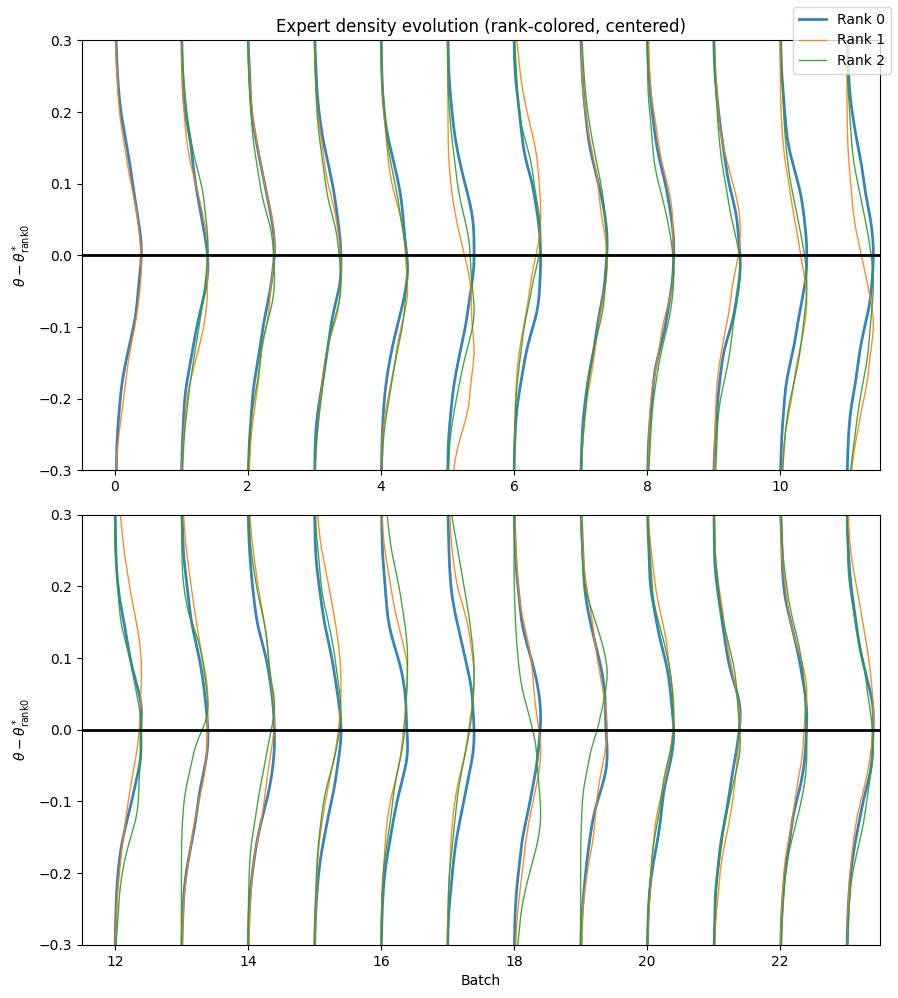

In [147]:
# plot_expert_density(batch_dict)
# plot_expert_density_ranked(batch_dict)
plot_expert_density_ranked_centered_split(batch_dict)

In [146]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import torch


def plot_expert_density_ranked_centered_split(
    batch_dict,
    grid_points=200,
    width=0.4,
    window=0.3,
    topk=None,
    split_threshold=10,
):

    B = len(batch_dict)

    # ===== 判断是否分割 =====
    if B <= split_threshold:
        fig, axes = plt.subplots(1, 1, figsize=(9, 5))
        axes = [axes]
        batch_splits = [sorted(batch_dict.keys())]
    else:
        fig, axes = plt.subplots(2, 1, figsize=(9, 10), sharey=True)

        sorted_batches = sorted(batch_dict.keys())
        mid = B // 2
        batch_splits = [
            sorted_batches[:mid],
            sorted_batches[mid:]
        ]

    labeled_ranks = set()

    for ax, batch_subset in zip(axes, batch_splits):

        for b in batch_subset:

            experts = batch_dict[b]

            experts_sorted = sorted(
                experts,
                key=lambda x: float(x[2]),
                reverse=True
            )

            if topk is not None:
                experts_sorted = experts_sorted[:topk]

            # ===== rank-0 mean =====
            p0, w0, _ = experts_sorted[0]
            p0 = p0.detach().cpu().numpy()
            w0 = w0.detach().cpu().numpy()
            theta_star = np.sum(p0 * w0)

            y_grid = np.linspace(-window, window, grid_points)

            for rank, (particles, weights, logmass) in enumerate(experts_sorted):

                p = particles.detach().cpu().numpy()
                w = weights.detach().cpu().numpy()

                centered_p = p - theta_star

                kde = gaussian_kde(centered_p, weights=w)
                density = kde(y_grid)

                if density.max() > 0:
                    density = density / density.max() * width
                else:
                    continue

                lw = 2.0 if rank == 0 else 1.0

                label = None
                if rank not in labeled_ranks:
                    label = f"Rank {rank}"
                    labeled_ranks.add(rank)

                ax.plot(
                    b + density,
                    y_grid,
                    color=f"C{rank % 10}",
                    linewidth=lw,
                    alpha=0.9,
                    label=label
                )

        ax.axhline(0.0, color="k", linewidth=2.0)
        ax.set_xlim(min(batch_subset) - 0.5, max(batch_subset) + 0.5)
        ax.set_ylim(-window, window)
        ax.set_ylabel(r"$\theta - \theta^*_{\mathrm{rank0}}$")

    axes[-1].set_xlabel("Batch")
    axes[0].set_title("Expert density evolution (rank-colored, centered)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()


In [151]:
import torch
data = torch.load("./figs/slope_deltaCmp_v1_debug/slope_0.001_seed456_batch10_results.pt", weights_only=False)
method_dict = {}
for name in ['BOCPD-PF', 'BOCPD-BPC', 'R-BOCPD-PF-usediscrepancy', 'R-BOCPD-PF-nodiscrepancy']:
    particles_total, weights_total = [], []
    for i in range(len(data[name]['top0_particles_hist'])):
        max_idx = torch.argmax(data[name]['top0_particles_hist'][i]["log_mass"])
        particles_total.append(data[name]['top0_particles_hist'][i]["particles"][max_idx].reshape(1, -1))
        try: 
            weights_total.append(data[name]['top0_particles_hist'][i]["weights"][max_idx].reshape(1, -1))
        except:
            weights_total.append(torch.ones(1, 500)/500)
        # print(data['BOCPD-PF']['top0_particles_hist'][i][0][max_idx])
    particles_total_bocpdpf = torch.cat(particles_total, dim=0)
    weights_total_bocpdpf = torch.cat(weights_total, dim=0)
    method_dict[name] = (particles_total_bocpdpf, weights_total_bocpdpf)

In [152]:
data["BOCPD-PF"]["theta_oracle"]

array([1.4962406 , 1.5112782 , 1.51879699, 1.52631579, 1.54135338,
       1.54887218, 1.56390977, 1.57142857, 1.57894737, 1.58646617,
       1.60150376, 1.60902256, 1.61654135, 1.63157895, 1.63909774,
       1.64661654, 1.66165414, 1.66917293, 1.68421053, 1.69172932,
       1.69924812, 1.71428571, 1.72180451, 1.72932331, 1.73684211,
       1.7518797 , 1.7593985 , 1.77443609, 1.78195489, 1.78947368,
       1.79699248, 1.81203008, 1.81954887, 1.83458647, 1.84210526,
       1.84962406, 1.85714286, 1.87218045, 1.87969925, 1.89473684,
       1.90225564, 1.90977444, 1.91729323, 1.93233083, 1.93984962,
       1.94736842, 1.96240602, 1.96992481, 1.97744361, 1.9924812 ,
       2.        , 2.0075188 , 2.02255639, 2.03007519, 2.03759398,
       2.05263158, 2.06015038, 2.06766917, 2.08270677, 2.09022556])

In [165]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import math


def plot_vertical_density_oracle_centered_multilayer(
    method_dict,
    oracle,
    grid_points=200,
    width=0.35,
    window=0.3,
    threshold=10
):

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    any_particles = list(method_dict.values())[0][0]
    B = any_particles.shape[0]

    oracle = np.asarray(oracle).reshape(-1)
    if len(oracle) != B:
        raise ValueError("oracle length must equal number of batches")

    # ===== 自动计算层数 =====
    n_rows = math.ceil(B / threshold)

    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(9, 5 * n_rows),
        sharey=True
    )

    if n_rows == 1:
        axes = [axes]

    labeled_methods = set()

    for row in range(n_rows):

        ax = axes[row]

        start = row * threshold
        end   = min((row + 1) * threshold, B)
        batch_subset = range(start, end)

        y_grid = np.linspace(-window, window, grid_points)

        for m_idx, (name, (particles, weights)) in enumerate(method_dict.items()):

            particles_np = particles.detach().cpu().numpy()
            weights_np   = weights.detach().cpu().numpy()

            for b in batch_subset:

                centered_particles = particles_np[b] - oracle[b]

                kde = gaussian_kde(
                    centered_particles,
                    weights=weights_np[b]
                )

                density = kde(y_grid)

                # if density.max() > 0:
                #     density = density / density.max() * width
                # else:
                #     continue
                dx = y_grid[1] - y_grid[0]
                area = np.sum(density) * dx

                density = density * width/3

                label = None
                if name not in labeled_methods:
                    label = name
                    labeled_methods.add(name)

                ax.plot(
                    b + density,
                    y_grid,
                    color=colors[m_idx % len(colors)],
                    alpha=0.8,
                    label=label
                )

        ax.axhline(0.0, color="k", linewidth=1.0)
        ax.set_xlim(start - 0.3, end - 1 + 0.3)
        ax.set_ylim(-window, window)
        ax.set_ylabel(r"$\theta - \theta^{*}$")

    axes[-1].set_xlabel("Batch")
    axes[0].set_title("Particle density evolution (oracle-centered)")

    # 统一 legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()


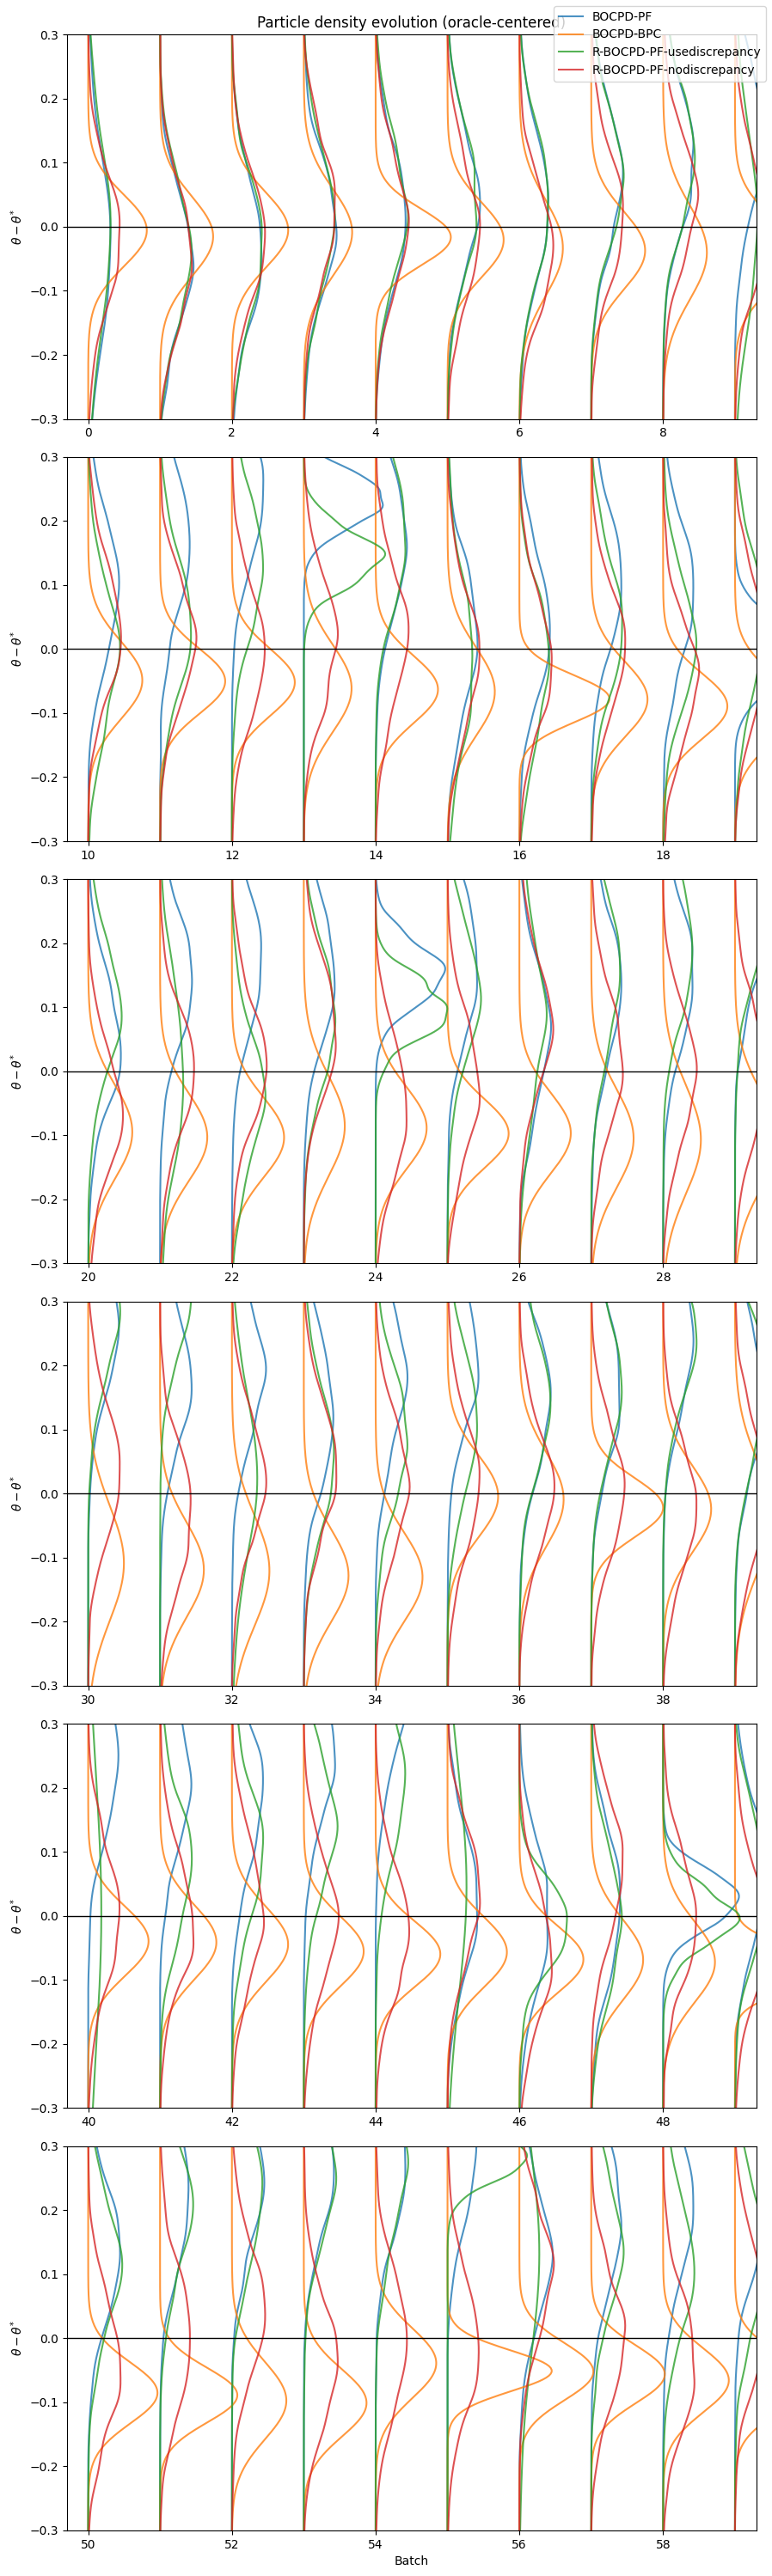

In [166]:

plot_vertical_density_oracle_centered_multilayer(method_dict, data["BOCPD-PF"]["theta_oracle"])

In [171]:
def plot_vertical_density(method_dict, grid_points=200, width=0.35, oracle=None, ymin=0, ymax=3):
    """
    method_dict:
        {
            "methodA": (particlesA, weightsA),
            "methodB": (particlesB, weightsB),
        }
    """

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    # 假设所有方法 B 相同
    any_particles = list(method_dict.values())[0][0]
    B, N = any_particles.shape

    # 全局 y-grid
    # all_particles = torch.cat(
    #     [v[0] for v in method_dict.values()],
    #     dim=0
    # ).detach().cpu().numpy()

    y_min, y_max = ymin, ymax
    y_grid = np.linspace(y_min, y_max, grid_points)

    plt.figure(figsize=(9,5))

    for m_idx, (name, (particles, weights)) in enumerate(method_dict.items()):

        particles = particles.detach().cpu().numpy()
        weights   = weights.detach().cpu().numpy()

        for b in range(B):

            kde = gaussian_kde(
                particles[b],
                weights=weights[b]
            )

            density = kde(y_grid)

            density = density / 3 * width

            # x_shift = b + (m_idx - len(method_dict)/2) * width
            x_shift = b

            if b == 0:
                plt.plot(
                    x_shift + density,
                    y_grid,
                    color=colors[m_idx],
                    alpha=0.8,
                    label=name
                )
            else:
                plt.plot(
                    x_shift + density,
                    y_grid,
                    color=colors[m_idx],
                    alpha=0.8
                )

    if oracle is not None:
        oracle = np.asarray(oracle).reshape(-1)
        if len(oracle) != B:
            raise ValueError(f"oracle length {len(oracle)} must equal B={B}")

        x = np.arange(B)
        plt.step(x, oracle, where="post", color="k", linewidth=2.0, label="oracle")

    plt.xlabel("Batch")
    plt.ylabel("Particle value")
    plt.title("Particle density evolution (multi-method)")
    plt.tight_layout()
    plt.legend()
    plt.show()

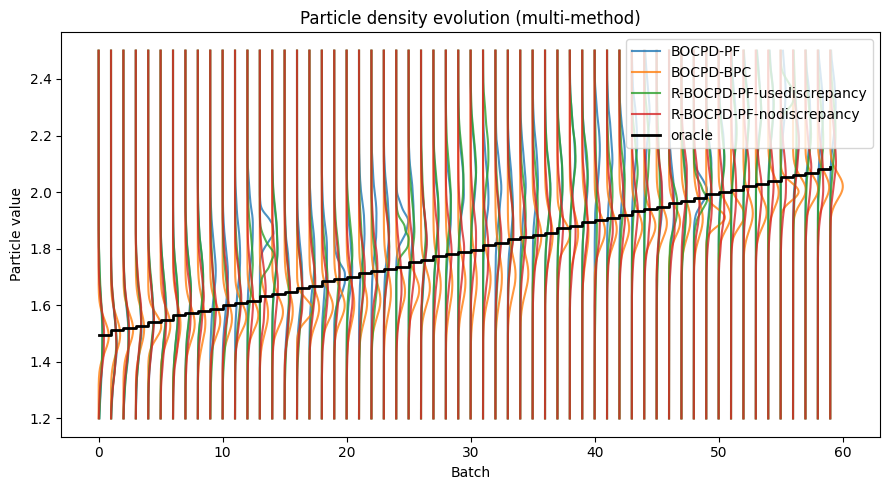

In [172]:
plot_vertical_density(method_dict, oracle=data["BOCPD-PF"]["theta_oracle"], ymin=1.2, ymax=2.5)